#Setup

In [1]:
#install python packages
!pip3 install -q geopandas openpyxl python-calamine requests tqdm beautifulsoup4
%pdb off

Automatic pdb calling has been turned OFF


In [2]:
#load python packages
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os
import math
import requests
import openpyxl
import pdb
%pdb on

Automatic pdb calling has been turned ON


# **Types of Ballot Errors in NYC City Council Elections with Ranked Choice Voting**


#Literature Review

## Ballot Errors

If people aren't filling out their ballots as intended, their preferences will not fully be accounted for. There are some cases where ballots with errors are still counted (for example, if the same candidate is ranked in 1st and 3rd), but in other cases, the ballot is thrown out altogether (for example, if two candidates are both ranked 1st).

The three types of errors I consider in this notebook are undervotes, overvotes and overranks. I elaborate on how these are measured and why while running the code later on.

While not strictly ballot errors, it is also important to consider the ballot exhaustion and futility rates—where a ballot is filled out correctly, but their ballot ultimately not counted because their choices have been "eliminated". More information on how these rates are calculated is available in [this report](https://mggg.org/PPM) on STV in Portland City Council Elections.

##Theory on RCV and Representation
Advocates of ranked-choice voting cite the potential for improved electoral representation as a major reason for implementing the policy. Since voters rank candidates rather than selecting a single one, each ballot can provide more information about a voter's preferences.

If successfully implemented, the policy also changes candidates' campaigning incentives—candidates now have to win over new constituencies as a 2nd or 3rd choice. This incentivizes both incumbents and challengers to be more responsive to preferences. RCV also challenges the idea of a "spoiler" candidate, since voters can rank candidates without worrying about their chances of winning.

However, these downstream benefits of representation can only occur if people are able to use the system in the first place. If it is the case that RCV depresses turnout rates, or exacerbates inequality in ballots utilized, it may do more harm than good. Following the 2021 NYC elections, critics of the policy highlighted how ballot errors and low ballot utiilization was highly concentrated in areas with historically marginalized populations (Anuta, Common Cause).

## Policy Issues

While ballot errors under vary across districts (as they do without RCV), these disparaties can be addressed through expanded voter education including:
- Multilingual resources explaining RCV
- Prioritizing in-person voter outreach (over digital/mailers)
- Incorporating RCV into existing civic education

I previously wrote a [case study paper](https://docs.google.com/document/d/1JFqdrA0fHGPUCMgDeCtqR-x_XiqBT389zlMpeDfxIwo/edit?usp=sharing) for an undergrad final on the implementation of RCV in the 2021 NYC mayoral election and published a [policy brief](https://rooseveltinstitute.org/publications/bold-ideas-emerging-leaders-2025/?utm_campaign=network20250730&utm_source=linkedin&utm_medium=social&utm_content=emergingfellows2025) on campaigns to pass RCV for the Roosevelt Network. Both of these contain more extensive recommendations, but I'm rapidly nearing the deadline and don't want to outright plagarize myself.


#Data Cleaning
This is the code I used to clean the original excel files but it takes > 1 hour to run on my computer. For best results, don't run anything in this section on Colab and just load the clean loaded from a csv in Part 1.

### Load the NYC election district shapefiles

## Collapsed Cleaning


In [3]:
import shapely.wkt

#load NYC election districts
nyc_ED_gdf = gpd.read_file(
    "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2020s_Election_Districts.csv"
)
# Convert WKT strings to geometry objects
nyc_ED_gdf['the_geom'] = nyc_ED_gdf['the_geom'].apply(shapely.wkt.loads)
nyc_ED_gdf = gpd.GeoDataFrame(nyc_ED_gdf, geometry="the_geom")
nyc_ED_gdf["elect_dist"] = nyc_ED_gdf["ElectDist"].replace(",", "", regex=True).astype(int)
nyc_ED_gdf = nyc_ED_gdf.drop(columns=["ElectDist"])

nyc_ED_gdf.head()

,the_geom,Shape_Length,Shape_Area,elect_dist
0,"MULTIPOLYGON (((-73.86287 40.56683, -73.86267 ...","41,787.6519145","34,529,587.207",23003
1,"MULTIPOLYGON (((-73.85274 40.57061, -73.85312 ...","13,616.939281","8,166,449.6783",23004
2,"MULTIPOLYGON (((-73.84878 40.57205, -73.84887 ...","10,698.5477342","5,077,744.89005",23005
3,"MULTIPOLYGON (((-73.84527 40.57332, -73.84616 ...","9,623.94455388","4,381,563.39557",23006
4,"MULTIPOLYGON (((-73.84621 40.58176, -73.84623 ...","8,943.399066","4,008,090.97296",23007


### Load the Primary CVR files

In [ ]:
#list of files to get from github
filenames_2021 = ["2021P1V1_ABS", "2021P1V1_AFF","2021P1V1_ELE1","2021P1V1_ELE2",
                  "2021P1V1_ELE3","2021P1V1_EMG","2021P2V1_ABS","2021P2V1_AFF",
                  "2021P2V1_ELE","2021P2V1_EMG","2021P3V1_ABS","2021P3V1_AFF",
                  "2021P3V1_ELE1","2021P3V1_ELE2","2021P3V1_ELE3","2021P3V1_ELE4",
                  "2021P3V1_EMG","2021P4V1_ABS_DEM","2021P4V1_ABS_REP_CON",
                  "2021P4V1_AFF", "2021P4V1_ELE1","2021P4V1_ELE2","2021P4V1_ELE3",
                  "2021P5V1_ELE","2021PV5_OTH"]
filenames_2023 = ["2023P1V1_EAR","2023P1V1_ELE","2023P1V1_OTH","2023P2V1_EAR",
                  "2023P2V1_ELE","2023P2V1_OTH","2023P3V1_EAR","2023P3V1_ELE",
                  "2023P3V1_OTH","2023P4V1_EAR","2023P4V1_ELE","2023P4V1_OTH"]
filenames_2025 = ["2025P1V1_ABS","2025P1V1_AFF","2025P1V1_EAR1","2025P1V1_EAR2",
                  "2025P1V1_ELE1","2025P1V1_ELE2","2025P1V1_EMG","2025P2V1_ABS",
                  "2025P2V1_AFF","2025P2V1_EAR","2025P2V1_ELE1","2025P2V1_ELE2",
                  "2025P2V1_EMG","2025P3V1_ABS","2025P3V1_AFF","2025P3V1_EAR1",
                  "2025P3V1_EAR2","2025P3V1_ELE1","2025P3V1_ELE2","2025P3V1_ELE3",
                  "2025P3V1_EMG","2025P4V1_ABS","2025P4V1_AFF","2025P4V1_EAR",
                  "2025P4V1_ELE1","2025P4V1_ELE2","2025P4V1_ELE3","2025P5V1_EAR",
                  "2025P5V1_ELE","2025P5V1_EMG","2025P5V1_OTH"]

#function to add excel suffix
def add_suffix(s, end = ".xlsx"):
    return s + end

filenames_2021 = list(map(add_suffix, filenames_2021))
filenames_2023 = list(map(add_suffix, filenames_2023))
filenames_2025 = list(map(add_suffix, filenames_2025))

In [ ]:
#store in empty list
nyc_CVR_2021P_df_list = []

#loop through files in the directory
nyc_CVR_2021_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2021_Primary_CVR/"

for file_name in filenames_2021:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2021_primary_folder + file_name)
    nyc_CVR_2021P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0
    )
    nyc_CVR_2021P_df_list.append(nyc_CVR_2021P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2021P_df_list:
    nyc_2021_primary_df = pd.concat(nyc_CVR_2021P_df_list, ignore_index=True)


2021P1V1_ABS.xlsx
2021P1V1_AFF.xlsx
2021P1V1_ELE1.xlsx
2021P1V1_ELE2.xlsx
2021P1V1_ELE3.xlsx
2021P1V1_EMG.xlsx
2021P2V1_ABS.xlsx
2021P2V1_AFF.xlsx
2021P2V1_ELE.xlsx
2021P2V1_EMG.xlsx
2021P3V1_ABS.xlsx
2021P3V1_AFF.xlsx
2021P3V1_ELE1.xlsx
2021P3V1_ELE2.xlsx
2021P3V1_ELE3.xlsx
2021P3V1_ELE4.xlsx
2021P3V1_EMG.xlsx
2021P4V1_ABS_DEM.xlsx
2021P4V1_ABS_REP_CON.xlsx
2021P4V1_AFF.xlsx
2021P4V1_ELE1.xlsx
2021P4V1_ELE2.xlsx
2021P4V1_ELE3.xlsx
2021P5V1_ELE.xlsx
2021PV5_OTH.xlsx


In [ ]:
nyc_CVR_2023P_df_list = []

#loop through files in the directory
nyc_CVR_2023_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2023_Primary_CVR/"

for file_name in filenames_2023:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2023_primary_folder + file_name)
    nyc_CVR_2023P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0,
    )
    nyc_CVR_2023P_df_list.append(nyc_CVR_2023P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2023P_df_list:
    nyc_2023_primary_df = pd.concat(nyc_CVR_2023P_df_list, ignore_index=True)


2023P1V1_EAR.xlsx
2023P1V1_ELE.xlsx
2023P1V1_OTH.xlsx
2023P2V1_EAR.xlsx
2023P2V1_ELE.xlsx
2023P2V1_OTH.xlsx
2023P3V1_EAR.xlsx
2023P3V1_ELE.xlsx
2023P3V1_OTH.xlsx
2023P4V1_EAR.xlsx
2023P4V1_ELE.xlsx
2023P4V1_OTH.xlsx


In [ ]:
nyc_CVR_2025P_df_list = []

#loop through files in the directory
nyc_CVR_2025_primary_folder = "https://raw.githubusercontent.com/zaramc/rcv-ballot-errors/main/NYC_2025_Primary_CVR/"

for file_name in filenames_2025:
    print(file_name)
    #construct the full file path
    file_path = (nyc_CVR_2025_primary_folder + file_name)
    nyc_CVR_2025P_df = pd.read_excel(
        file_path,
        engine="calamine",
        header=0,
    )
    nyc_CVR_2025P_df_list.append(nyc_CVR_2025P_df)

#concatenate all dataframes in the list into one
if nyc_CVR_2025P_df_list:
    nyc_2025_primary_df = pd.concat(nyc_CVR_2025P_df_list, ignore_index=True)


2025P1V1_ABS.xlsx
2025P1V1_AFF.xlsx
2025P1V1_EAR1.xlsx
2025P1V1_EAR2.xlsx
2025P1V1_ELE1.xlsx
2025P1V1_ELE2.xlsx
2025P1V1_EMG.xlsx
2025P2V1_ABS.xlsx
2025P2V1_AFF.xlsx
2025P2V1_EAR.xlsx
2025P2V1_ELE1.xlsx
2025P2V1_ELE2.xlsx
2025P2V1_EMG.xlsx
2025P3V1_ABS.xlsx
2025P3V1_AFF.xlsx
2025P3V1_EAR1.xlsx
2025P3V1_EAR2.xlsx
2025P3V1_ELE1.xlsx
2025P3V1_ELE2.xlsx
2025P3V1_ELE3.xlsx
2025P3V1_EMG.xlsx
2025P4V1_ABS.xlsx
2025P4V1_AFF.xlsx
2025P4V1_EAR.xlsx
2025P4V1_ELE1.xlsx
2025P4V1_ELE2.xlsx
2025P4V1_ELE3.xlsx
2025P5V1_EAR.xlsx
2025P5V1_ELE.xlsx
2025P5V1_EMG.xlsx
2025P5V1_OTH.xlsx


###Keep only relevant columns

In [5]:
#create lists of columns for filtering
council_col_25 = [col for col in nyc_2025_primary_df if "Council" in col]
col_25 = ["Precinct"] + council_col_25

council_col_23 = [col for col in nyc_2023_primary_df if "Council" in col]
col_23 = ["Precinct"] + council_col_23

council_col_21 = [col for col in nyc_2021_primary_df if "Council" in col]
col_21 = ["Precinct"] + [] + council_col_21


In [ ]:
#apply filters
nyc_2025_primary_df = nyc_2025_primary_df[col_25]
nyc_2023_primary_df = nyc_2023_primary_df[col_23]
nyc_2021_primary_df = nyc_2021_primary_df[col_21]

###Separate precinct info + prepare for shapefile joining

In [ ]:
nyc_2021_primary_df["AD"] = nyc_2021_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2021_primary_df["ED"] = nyc_2021_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2021_primary_df["ElectDist"] = nyc_2021_primary_df["AD"] + nyc_2021_primary_df["ED"]

nyc_2023_primary_df["AD"] = nyc_2023_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2023_primary_df["ED"] = nyc_2023_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2023_primary_df["ElectDist"] = nyc_2023_primary_df["AD"] + nyc_2023_primary_df["ED"]

nyc_2025_primary_df["AD"] = nyc_2025_primary_df["Precinct"].str.slice(start = 4, stop = 6)
nyc_2025_primary_df["ED"] = nyc_2025_primary_df["Precinct"].str.slice(start = 11, stop = 14)
nyc_2025_primary_df["ElectDist"] = nyc_2025_primary_df["AD"] + nyc_2025_primary_df["ED"]

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/957218774.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["AD"] = nyc_2021_primary_df["Precinct"].str.slice(start = 4, stop = 6)
/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/957218774.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["ED"] = nyc_2021_primary_df["Precinct"].str.slice(start = 11, stop = 14)
/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/957218774.py:3: PerformanceWarn

# Measuring Ballot Errors

The three types of ballot errors I measure in this notebook are **undervotes**, **over-ranking** and **over-voting** (duplicate votes). The processes I used are outlined in the sections below.

For more information on measuring ballot errors in general see: https://mathematics-democracy-institute.org/deficiencies-in-recent-research-on-ranked-choice-voting-ballot-error-rates/

## Processing ballots in NYC
The NYC Board of Elections releases CVR data without a dictionary/codebook, so I relied on [this resource](https://gist.github.com/anbnyc/282646575f41fabf41da239cbc9ace1f) to interpret CVR results and make an educated guess on how different types of ballot errors are handled.

###Undervotes
For the purposes of this notebook, an "undervote" is defined as when a voter ranks only one candidate in the race they are voting on, provided there are more than two candidates running.

This is different from how the NYC CVR dataset uses the term undervote. In the original data, if a voter lives in District A and ranks the maximum number of candidates for city council, the CVR would still record them as "undervote" for the District B race, even though they were not eligible for that election. But for the purposes of this notebook, that's not a ballot error in practice (it's voter fraud).

Note: The NYC CVR data does indicate how many candidates were eligible for each race with the names of the columns (e.g. District X, choice 1 out of Y would have Y possible choices). I couldn't find a good way to handle this for all 50+ districts across three election cycles. The way this code is written, as long as at least one candidate is ranked per race with 3 or more candidates it is not counted as an undervote. Votes for one candidate in a race with two candidates are not counted as undervotes.

In [17]:
vote_choice_cols_21 = [col for col in council_col_21 if "1 of 1" not in col and "1 of 2" not in col]

vote_choice_cols_23 = [col for col in council_col_23 if "1 of 1" not in col and "1 of 2" not in col]

vote_choice_cols_25 = [col for col in council_col_25 if "1 of 1" not in col and "1 of 2" not in col]

In [ ]:
def count_valid_numeric_21(row):
    def is_numeric_value(val):
        if pd.isna(val):
            return False
        # Check if it's already a number (int, float)
        if isinstance(val, (int, float)):
            return True
        # If it's a string, check if it's a digit
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_value(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_21)

nyc_2021_primary_df["valid_numeric_votes"] = nyc_2021_primary_df.apply(count_valid_numeric_21, axis=1)

# quick check
nyc_2021_primary_df["valid_numeric_votes"].value_counts()

nyc_2021_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2021_primary_df['valid_numeric_votes']]
nyc_2021_primary_df["undervote"].value_counts()

In [ ]:
def count_valid_numeric_23(row):
    def is_numeric_value(val):
        if pd.isna(val):
            return False
        # Check if it's already a number (int, float)
        if isinstance(val, (int, float)):
            return True
        # If it's a string, check if it's a digit
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_value(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_23)

nyc_2023_primary_df["valid_numeric_votes"] = nyc_2023_primary_df.apply(count_valid_numeric_23, axis=1)

# quick check
nyc_2023_primary_df["valid_numeric_votes"].value_counts()

nyc_2023_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2023_primary_df['valid_numeric_votes']]
nyc_2023_primary_df["undervote"].value_counts()

In [ ]:
def count_valid_numeric_25(row):
    def is_numeric_value(val):
        if pd.isna(val):
            return False
        # Check if it's already a number (int, float)
        if isinstance(val, (int, float)):
            return True
        # If it's a string, check if it's a digit
        if isinstance(val, str):
            return val.isdigit()
        return False
    return sum(is_numeric_value(row[col]) or row[col] == "Write-in" for col in vote_choice_cols_25)

nyc_2025_primary_df["valid_numeric_votes"] = nyc_2025_primary_df.apply(count_valid_numeric_25, axis=1)

# quick check
nyc_2025_primary_df["valid_numeric_votes"].value_counts()

nyc_2025_primary_df["undervote"] = [0 if x >= 1 else 1 for x in nyc_2025_primary_df['valid_numeric_votes']]
nyc_2025_primary_df["undervote"].value_counts()

###Over-voting
When a ballot begins with an overvote (e.g. the voter ranked both Eric Adams and Andrew Yang first), the BOE discards the vote, since there is no way to determine which of the two options the voter prefers.

In [ ]:
def count_overvote_21(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_21]) else 0

nyc_2021_primary_df["overvote"] = nyc_2021_primary_df.apply(count_overvote_21, axis=1)
nyc_2021_primary_df["overvote"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/3659778032.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["overvote"] = nyc_2021_primary_df.apply(count_overvote_21, axis=1)


overvote
0    1063261
1       6458
Name: count, dtype: int64

In [ ]:
def count_overvote_23(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_23]) else 0

nyc_2023_primary_df["overvote"] = nyc_2023_primary_df.apply(count_overvote_23, axis=1)
nyc_2023_primary_df["overvote"].value_counts()

overvote
0    202617
1      1102
Name: count, dtype: int64

In [ ]:
def count_overvote_25(row):
    return 1 if any(x == "overvote" for x in row[vote_choice_cols_25]) else 0

nyc_2025_primary_df["overvote"] = nyc_2025_primary_df.apply(count_overvote_25, axis=1)
nyc_2025_primary_df["overvote"].value_counts()

overvote
0    1111549
1       2884
Name: count, dtype: int64

###Duplicate rankings (a.k.a "over-ranking")
Duplicate rankings occur when a voter ranks the same candidate for the same position multiple times on their ballot.

For example, if a voter ranked:
1. Zohran Mamdani
2. Brad Lander
3. Zohran Mamdani
4. Andrew Cuomo

The BOE would process it as first choice Mamdani, second choice Lander (ignore the second time Mamdani was ranked), third choice Cuomo. Unlike overvotes, ballots with duplicate rankings are *not* discarded, since some information about voter preferences can still be determined.

In [ ]:
def count_duplicate_21(row):
    values = row[vote_choice_cols_21]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2021_primary_df["duplicate"] = nyc_2021_primary_df.apply(count_duplicate_21, axis=1)
nyc_2021_primary_df["duplicate"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/1354972690.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2021_primary_df["duplicate"] = nyc_2021_primary_df.apply(count_duplicate_21, axis=1)


duplicate
0    1056259
1      13460
Name: count, dtype: int64

In [ ]:
def count_duplicate_23(row):
    values = row[vote_choice_cols_23]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2023_primary_df["duplicate"] = nyc_2023_primary_df.apply(count_duplicate_23, axis=1)
nyc_2023_primary_df["duplicate"].value_counts()

duplicate
0    198649
1      5070
Name: count, dtype: int64

In [ ]:
def count_duplicate_25(row):
    values = row[vote_choice_cols_25]
    s = pd.Series([v for v in values if pd.notna(v) and v != "undervote" and v != "overvote" and v != "Write-in"])
    return 0 if s.is_unique else 1

nyc_2025_primary_df["duplicate"] = nyc_2025_primary_df.apply(count_duplicate_25, axis=1)
nyc_2025_primary_df["duplicate"].value_counts()

/var/folders/1r/77kyrvnj71v8ffbc6w6wj78h0000gn/T/ipykernel_41112/448643074.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nyc_2025_primary_df["duplicate"] = nyc_2025_primary_df.apply(count_duplicate_25, axis=1)


duplicate
0    1106021
1       8412
Name: count, dtype: int64

get CSVs for all above files so you don't have to redo this cleaning one billion times

In [ ]:
# save csvs
import os

cleaned_dir = "/Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data"
os.makedirs(cleaned_dir, exist_ok=True)

for df_name, df in [
    ("nyc_2021_primary_df_clean", nyc_2021_primary_df),
    ("nyc_2023_primary_df_clean", nyc_2023_primary_df),
    ("nyc_2025_primary_df_clean", nyc_2025_primary_df),
]:
    out_path = os.path.join(cleaned_dir, f"{df_name}.csv")
    try:
        df.to_csv(out_path, index=False)
        print(f"Saved {out_path}")
    except Exception as e:
        print(f"Failed to save {out_path}: {e}")

Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2021_primary_df_clean.csv
Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2023_primary_df_clean.csv
Saved /Users/zarachapple/Desktop/school/classes/DATA_30195/Final_Project/cleaned_data/nyc_2025_primary_df_clean.csv


##Load cleaned data
The clean datasets are very large (100s of MB) and cannot be easily downloaded from Google Drive or GitHub in Colab. They can be downloaded locally [here](https://drive.google.com/drive/folders/1cL7Uhj75WYPrDZvigJ7KT8lhFQff7M6q?usp=drive_link) and then uploaded to Colab.

In [4]:
nyc_2021_primary_df = pd.read_csv("nyc_2021_primary_df_clean.csv", low_memory=False)

nyc_2023_primary_df = pd.read_csv("nyc_2023_primary_df_clean.csv", low_memory=False)

nyc_2025_primary_df = pd.read_csv("nyc_2025_primary_df_clean.csv", low_memory=False)

In [7]:
nyc_2021_primary_df['elect_dist'] = nyc_2021_primary_df['ElectDist'].astype(pd.Int64Dtype())
nyc_2021_primary_df = nyc_2021_primary_df.drop(columns=["ElectDist"])

nyc_2023_primary_df['elect_dist'] = nyc_2023_primary_df['ElectDist'].astype(pd.Int64Dtype())
nyc_2023_primary_df = nyc_2023_primary_df.drop(columns=["ElectDist"])

nyc_2025_primary_df['elect_dist'] = nyc_2025_primary_df['ElectDist'].astype(pd.Int64Dtype())
nyc_2025_primary_df = nyc_2025_primary_df.drop(columns=["ElectDist"])

nyc_2021_primary_df.head()

,Precinct,DEM Council Member Choice 1 of 3 2nd Council District (024463),DEM Council Member Choice 2 of 3 2nd Council District (224463),DEM Council Member Choice 3 of 3 2nd Council District (324463),DEM Council Member Choice 1 of 5 10th Council District (024370),DEM Council Member Choice 2 of 5 10th Council District (224370),DEM Council Member Choice 3 of 5 10th Council District (324370),DEM Council Member Choice 4 of 5 10th Council District (424370),DEM Council Member Choice 5 of 5 10th Council District (524370),DEM Council Member Choice 1 of 5 1st Council District (024340),...,REP Council Member Choice 3 of 5 50th Council District (324367),REP Council Member Choice 4 of 5 50th Council District (424367),REP Council Member Choice 5 of 5 50th Council District (524367),AD,ED,valid_numeric_votes,undervote,overvote,duplicate,elect_dist
0,AD: 66 ED: 028,221474,undervote,undervote,undervote,undervote,undervote,undervote,undervote,undervote,...,NaN,NaN,NaN,66,28,1,0,0,0,66028
1,AD: 66 ED: 028,221474,217703,undervote,undervote,undervote,undervote,undervote,undervote,undervote,...,NaN,NaN,NaN,66,28,2,0,0,0,66028
2,AD: 66 ED: 028,221474,undervote,undervote,undervote,undervote,undervote,undervote,undervote,undervote,...,NaN,NaN,NaN,66,28,1,0,0,0,66028
3,AD: 66 ED: 028,217703,undervote,undervote,undervote,undervote,undervote,undervote,undervote,undervote,...,NaN,NaN,NaN,66,28,1,0,0,0,66028
4,AD: 66 ED: 028,217703,undervote,undervote,undervote,undervote,undervote,undervote,undervote,undervote,...,NaN,NaN,NaN,66,28,1,0,0,0,66028


# Part I: Visualizing ballot errors across the city


In [18]:
# ignore two-candidate races when visualizing errors
vote_choice_cols_21 = vote_choice_cols_21 + ["elect_dist"]
nyc_2021_primary_df = nyc_2021_primary_df[vote_choice_cols_21]

In [19]:
vote_choice_cols_23 = vote_choice_cols_23 + ["elect_dist"]
nyc_2023_primary_df = nyc_2023_primary_df[vote_choice_cols_23]

In [ ]:
vote_choice_cols_25 = vote_choice_cols_25 + ["elect_dist"]
nyc_2025_primary_df = nyc_2025_primary_df[vote_choice_cols_25]

In [1]:
nyc_2021_primary_df.head()

NameError: name 'nyc_2021_primary_df' is not defined

In [24]:
# get total counts of votes by ElectDist and rename columns for clarity
total_votes_by_electdist_21 = nyc_2021_primary_df["elect_dist"].value_counts().reset_index()
total_votes_by_electdist_21 = total_votes_by_electdist_21.rename(columns={'count': 'total_votes_21_count'})

total_votes_by_electdist_23 = nyc_2023_primary_df["elect_dist"].value_counts().reset_index()
total_votes_by_electdist_23 = total_votes_by_electdist_23.rename(columns={'count': 'total_votes_23_count'})

total_votes_by_electdist_25 = nyc_2025_primary_df["elect_dist"].value_counts().reset_index()
total_votes_by_electdist_25 = total_votes_by_electdist_25.rename(columns={'count': 'total_votes_25_count'})


# Add total vote counts to ED GDF with a single merge operation
nyc_ED_gdf = pd.merge(nyc_ED_gdf, total_votes_by_electdist_21, on="elect_dist", how="outer")
nyc_ED_gdf = pd.merge(nyc_ED_gdf, total_votes_by_electdist_23, on="elect_dist", how="outer")
nyc_ED_gdf = pd.merge(nyc_ED_gdf, total_votes_by_electdist_25, on="elect_dist", how="outer")

nyc_ED_gdf.head()

KeyError: 'elect_dist'

> /usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py(3812)get_loc()
   3810             ):
   3811                 raise InvalidIndexError(key)
-> 3812             raise KeyError(key) from err
   3813         except TypeError:
   3814             # If we have a listlike key, _check_indexing_error will raise

--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user


##Undervotes
1. Apply previously defined function to calculate undervotes by election district
2. Visualize with matplotlib
3. Summarize results

In [11]:
#get counts of undervotes by ElectDist
undervotes_by_electdist_21 = nyc_2021_primary_df.groupby("elect_dist")["undervote"].sum().reset_index()
undervotes_by_electdist_23 = nyc_2023_primary_df.groupby("elect_dist")["undervote"].sum().reset_index()
undervotes_by_electdist_25 = nyc_2025_primary_df.groupby("elect_dist")["undervote"].sum().reset_index()

#join to shapefile
nyc_ED_gdf = pd.merge(undervotes_by_electdist_21, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'undervote': 'undervote21'})

nyc_ED_gdf = pd.merge(undervotes_by_electdist_23, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'undervote': 'undervote23'})

nyc_ED_gdf = pd.merge(undervotes_by_electdist_25, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'undervote': 'undervote25'})

In [13]:
#add undervote percents
nyc_ED_gdf["pct_undervote21"] = nyc_ED_gdf["undervote21"]/nyc_ED_gdf["total_votes_21_count"]
nyc_ED_gdf["pct_undervote23"] = nyc_ED_gdf["undervote23"]/nyc_ED_gdf["total_votes_23_count"]
nyc_ED_gdf["pct_undervote25"] = nyc_ED_gdf["undervote25"]/nyc_ED_gdf["total_votes_25_count"]

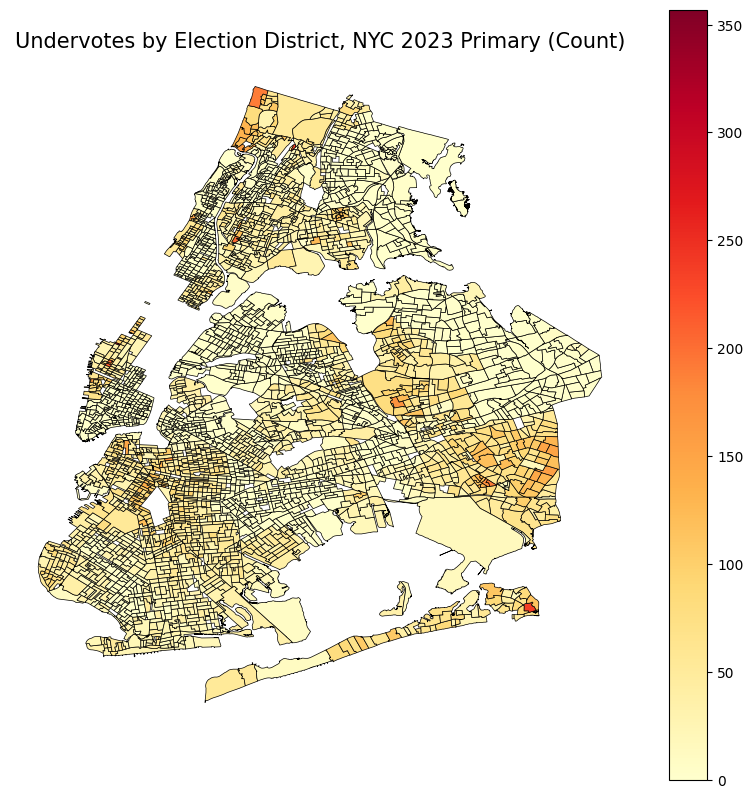

In [93]:
nyc_ED_gdf = gpd.GeoDataFrame(nyc_ED_gdf, geometry="the_geom")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nyc_ED_gdf.plot(ax=ax,
                column="undervote23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)
ax.set_title("Undervotes by Election District, NYC 2023 Primary (Count)", fontsize=15)
ax.set_axis_off()
plt.show()

##Overvotes

In [94]:
#get counts of overvotes by ElectDist
overvotes_by_electdist_21 = nyc_2021_primary_df.groupby("elect_dist")["overvote"].sum().reset_index()
overvotes_by_electdist_23 = nyc_2023_primary_df.groupby("elect_dist")["overvote"].sum().reset_index()
overvotes_by_electdist_25 = nyc_2025_primary_df.groupby("elect_dist")["overvote"].sum().reset_index()

#join to shapefile
nyc_ED_gdf = pd.merge(overvotes_by_electdist_21, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'overvote': 'overvote21'})

nyc_ED_gdf = pd.merge(overvotes_by_electdist_23, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'overvote': 'overvote23'})

nyc_ED_gdf = pd.merge(overvotes_by_electdist_25, nyc_ED_gdf, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'overvote': 'overvote25'})



In [14]:
#add overvote percents
nyc_ED_gdf["pct_overvote21"] = nyc_ED_gdf["overvote21"]/nyc_ED_gdf["total_votes_21_count"]
nyc_ED_gdf["pct_overvote23"] = nyc_ED_gdf["overvote23"]/nyc_ED_gdf["total_votes_23_count"]
nyc_ED_gdf["pct_overvote25"] = nyc_ED_gdf["overvote25"]/nyc_ED_gdf["total_votes_25_count"]

nyc_ED_gdf.head()


KeyError: 'overvote21'

> /usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py(3812)get_loc()
   3810             ):
   3811                 raise InvalidIndexError(key)
-> 3812             raise KeyError(key) from err
   3813         except TypeError:
   3814             # If we have a listlike key, _check_indexing_error will raise

--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user


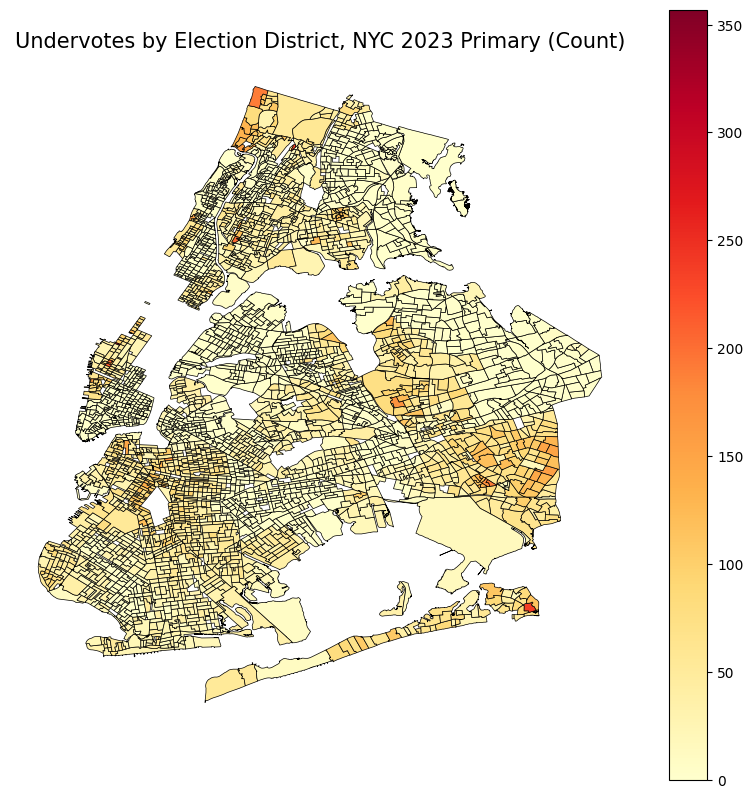

In [96]:
nyc_ED_gdf = gpd.GeoDataFrame(nyc_ED_gdf, geometry="the_geom")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nyc_ED_gdf.plot(ax=ax,
                column="undervote23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)
ax.set_title("Undervotes by Election District, NYC 2023 Primary (Count)", fontsize=15)
ax.set_axis_off()
plt.show()

## Duplicate votes

In [97]:
duplicates_by_electdist_23 = nyc_2023_primary_df.groupby("elect_dist")["duplicate"].sum().reset_index()

In [98]:
duplicates_by_electdist_21 = nyc_2021_primary_df.groupby("elect_dist")["duplicate"].sum().reset_index()
nyc_ED_gdf = pd.merge(nyc_ED_gdf, duplicates_by_electdist_21, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'duplicate': 'duplicate21'})

duplicates_by_electdist_23 = nyc_2023_primary_df.groupby("elect_dist")["duplicate"].sum().reset_index()
nyc_ED_gdf = pd.merge(nyc_ED_gdf, duplicates_by_electdist_23, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'duplicate': 'duplicate23'})

duplicates_by_electdist_25 = nyc_2025_primary_df.groupby("elect_dist")["duplicate"].sum().reset_index()
nyc_ED_gdf = pd.merge(nyc_ED_gdf, duplicates_by_electdist_25, left_on="elect_dist", right_on="elect_dist", how="left")
nyc_ED_gdf = nyc_ED_gdf.rename(columns={'duplicate': 'duplicate25'})

In [99]:
#add duplicate percents
nyc_ED_gdf["pct_duplicate21"] = nyc_ED_gdf["duplicate21"]/nyc_ED_gdf["total_votes_21_count"]
nyc_ED_gdf["pct_duplicate23"] = nyc_ED_gdf["duplicate23"]/nyc_ED_gdf["total_votes_23_count"]
nyc_ED_gdf["pct_duplicate25"] = nyc_ED_gdf["duplicate25"]/nyc_ED_gdf["total_votes_25_count"]

nyc_ED_gdf.head()


,elect_dist,overvote25,overvote23,overvote21,undervote25,undervote23,undervote21,the_geom,Shape_Length,Shape_Area,...,pct_undervote25,pct_overvote21,pct_overvote23,pct_overvote25,duplicate21,duplicate23,duplicate25,pct_duplicate21,pct_duplicate23,pct_duplicate25
0,23001,0,0.0,1.0,300.0,52.0,39.0,"MULTIPOLYGON (((-73.92033 40.56223, -73.92078 ...","24,592.6582449","27,791,292.864",...,1.0,0.003236,0.0,0.0,4.0,0.0,0,0.012945,0.0,0.0
1,23002,0,0.0,1.0,269.0,51.0,47.0,"MULTIPOLYGON (((-73.91017 40.56492, -73.91039 ...","15,530.3167563","9,753,394.38439",...,1.0,0.003086,0.0,0.0,11.0,0.0,0,0.033951,0.0,0.0
2,23003,0,0.0,1.0,63.0,10.0,35.0,"MULTIPOLYGON (((-73.86287 40.56683, -73.86267 ...","41,787.6519145","34,529,587.207",...,1.0,0.003953,0.0,0.0,2.0,0.0,0,0.007905,0.0,0.0
3,23004,0,0.0,0.0,385.0,79.0,4.0,"MULTIPOLYGON (((-73.85274 40.57061, -73.85312 ...","13,616.939281","8,166,449.6783",...,1.0,0.0,0.0,0.0,2.0,0.0,0,0.043478,0.0,0.0
4,23005,0,0.0,0.0,329.0,86.0,37.0,"MULTIPOLYGON (((-73.84878 40.57205, -73.84887 ...","10,698.5477342","5,077,744.89005",...,1.0,0.0,0.0,0.0,2.0,0.0,0,0.007874,0.0,0.0


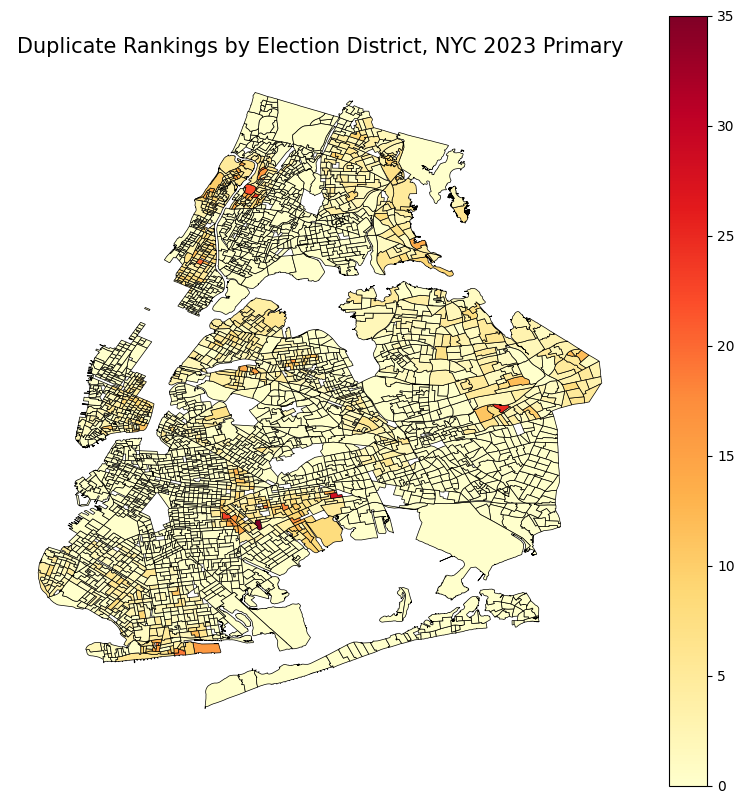

In [102]:
nyc_ED_gdf = gpd.GeoDataFrame(nyc_ED_gdf, geometry="the_geom")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
nyc_ED_gdf.plot(ax=ax,
                column="duplicate23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)
ax.set_title("Duplicate Rankings by Election District, NYC 2023 Primary", fontsize=15)
ax.set_axis_off()
plt.show()

#Part II: Ballot error distribution over time

## Undervotes

AttributeError: Line2D.set() got an unexpected keyword argument 'edgecolor'

> /usr/local/lib/python3.12/dist-packages/matplotlib/artist.py(1206)_update_props()
   1204                     func = getattr(self, f"set_{k}", None)
   1205                     if not callable(func):
-> 1206                         raise AttributeError(
   1207                             errfmt.format(cls=type(self), prop_name=k),
   1208                             name=k)

--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user


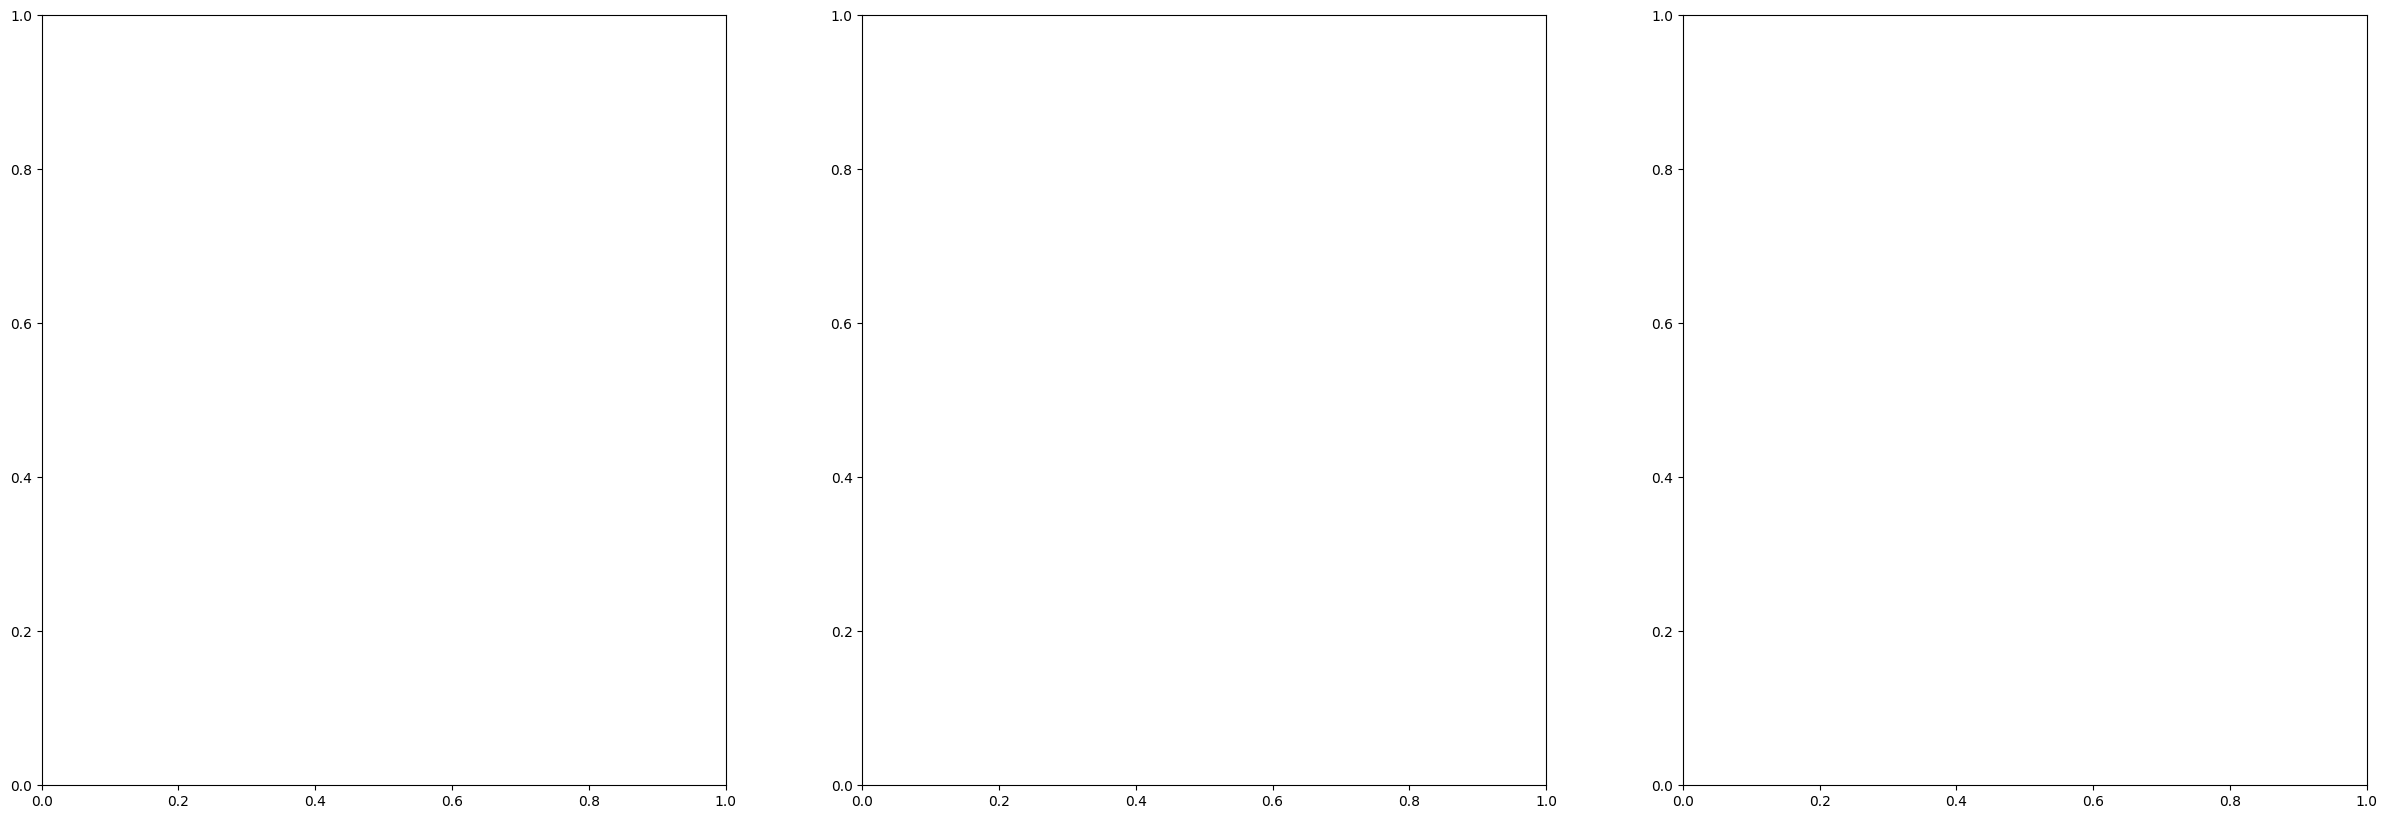

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
nyc_ED_gdf.plot(ax=axes[0],
                column="pct_undervote21",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[1],
                column="pct_undervote23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[2],
                column="pct_undervote25",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

axes[0].set_title("2021 Undervotes", fontsize=15)
axes[0].set_axis_off()

axes[1].set_title("2023 Undervotes", fontsize=15)
axes[1].set_axis_off()

axes[2].set_title("2025 Undervotes", fontsize=15)
axes[2].set_axis_off()

plt.show()

## Overvotes

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
nyc_ED_gdf.plot(ax=axes[0],
                column="pct_overvote21",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[1],
                column="pct_overvote23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[2],
                column="pct_overvote25",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

axes[0].set_title("2021 Overvotes", fontsize=15)
axes[0].set_axis_off()

axes[1].set_title("2023 Overvotes", fontsize=15)
axes[1].set_axis_off()

axes[2].set_title("2025 Overvotes", fontsize=15)
axes[2].set_axis_off()

plt.show()

## Duplicates

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
nyc_ED_gdf.plot(ax=axes[0],
                column="pct_duplicate23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[1],
                column="pct_duplicate23",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

nyc_ED_gdf.plot(ax=axes[2],
                column="pct_duplicate25",
                legend=True,
                cmap="YlOrRd",
                edgecolor = "black",
                linewidth = 0.5)

axes[0].set_title("2021 Duplicates", fontsize=15)
axes[0].set_axis_off()

axes[1].set_title("2023 Duplicates", fontsize=15)
axes[1].set_axis_off()

axes[2].set_title("2025 Duplicates", fontsize=15)
axes[2].set_axis_off()

plt.show()

#References

Study of the 2024 STV City Council Election
in Portland, Oregon
https://mggg.org/PPM

Voting Error across Multiple Ballot Types: Results from Super Tuesday (2020) Experiments in Four American States
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3697637

Report: Deficiencies in Recent Research on Ranked Choice Voting Ballot Error Rates
https://mathematics-democracy-institute.org/deficiencies-in-recent-research-on-ranked-choice-voting-ballot-error-rates/

Ballot (and Voter) 'Exhaustion' Under Instant Runoff Voting: An Examination of Four Ranked-Choice Elections
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2519723

Is Ranked-Choice Voting Associated With Turnout Across
Race/Ethnic Groups?
https://onlinelibrary.wiley.com/doi/pdf/10.1111/ssqu.70025

Does ranked choice Voting Increase voter turnout and mobilization?
https://www.sciencedirect.com/science/article/pii/S026137942400074X?via%3Dihub

The Impact of Ranked Choice Voting on the
Democratic Primary Elections of 2021
https://www.gc.cuny.edu/sites/default/files/2022-07/CUR-Report-on-RCV-Final.pdf

Ranked choice voting elections benefit candidates and voters of color: 2024 update
https://fairvote.org/report/communities-of-color-2024/?section=executive-summary